# Mini Project 3: CNN on CIFAR-10
Neural Networks and Deep Learning

## Part 1: Environment Setup, Data Loading, and Preprocessing

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

import warnings
warnings.filterwarnings('ignore')

# Reproducibility seeds
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Project folders
os.makedirs('data', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

c:\Reza\Python\Python312\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Device: cpu


In [2]:
# CIFAR-10 class names
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# CIFAR-10 dataset path (adjust if needed)
# Expected structure: data/cifar-10-batches-py/
CIFAR_PATH = '.'

def load_cifar_batch(filepath):
    with open(filepath, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    data = batch[b'data']          # shape (N, 3072) uint8
    labels = np.array(batch[b'labels'], dtype=np.int32)
    return data, labels

def load_cifar10(root):
    train_data_list, train_labels_list = [], []
    for i in range(1, 6):
        d, l = load_cifar_batch(os.path.join(root, f'data_batch_{i}'))
        train_data_list.append(d)
        train_labels_list.append(l)
    train_data   = np.concatenate(train_data_list, axis=0)
    train_labels = np.concatenate(train_labels_list, axis=0)
    test_data, test_labels = load_cifar_batch(os.path.join(root, 'test_batch'))
    return train_data, train_labels, test_data, test_labels

train_data, train_labels, test_data, test_labels = load_cifar10(CIFAR_PATH)

print('=== General Info ===')
print(f'train_data shape : {train_data.shape}, dtype: {train_data.dtype}')
print(f'train_labels shape: {train_labels.shape}, dtype: {train_labels.dtype}')
print(f'test_data shape  : {test_data.shape}, dtype: {test_data.dtype}')
print(f'test_labels shape : {test_labels.shape}, dtype: {test_labels.dtype}')
print(f'Pixel range — min: {train_data.min()}, max: {train_data.max()}')
print(f'Image size: 32x32, channels: 3')

=== General Info ===
train_data shape : (50000, 3072), dtype: uint8
train_labels shape: (50000,), dtype: int32
test_data shape  : (10000, 3072), dtype: uint8
test_labels shape : (10000,), dtype: int32
Pixel range — min: 0, max: 255
Image size: 32x32, channels: 3


In [3]:
# Stratified split: 5000 val, 45000 train_final
sss = StratifiedShuffleSplit(n_splits=1, test_size=5000, random_state=SEED)
train_idx, val_idx = next(sss.split(train_data, train_labels))

X_train_full  = train_data
y_train_full  = train_labels
X_train_final = train_data[train_idx]
y_train_final = train_labels[train_idx]
X_val         = train_data[val_idx]
y_val         = train_labels[val_idx]
X_test        = test_data
y_test        = test_labels

print(f'Train final : {X_train_final.shape[0]} samples')
print(f'Validation  : {X_val.shape[0]} samples')
print(f'Test        : {X_test.shape[0]} samples')

# Verify per-class counts
for split_name, labels in [('train_final', y_train_final), ('val', y_val)]:
    counts = np.bincount(labels, minlength=10)
    print(f'{split_name}: min={counts.min()}, max={counts.max()}, balanced={counts.min()==counts.max()}')

Train final : 45000 samples
Validation  : 5000 samples
Test        : 10000 samples
train_final: min=4500, max=4500, balanced=True
val: min=500, max=500, balanced=True


In [4]:
# CIFAR-10 official mean and std (per channel, computed on training set)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

# Transforms: no augmentation (base)
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# Augmentation transform (only used on training set in Part 5)
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

print('Transforms defined.')

Transforms defined.


In [5]:
from PIL import Image

class CIFAR10Dataset(Dataset):
    """Custom Dataset for raw CIFAR-10 numpy arrays."""
    def __init__(self, data, labels, transform=None):
        # data: (N, 3072) uint8
        self.data      = data
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Reshape flat 3072 → (3,32,32) → (32,32,3) for PIL
        img = self.data[idx].reshape(3, 32, 32).transpose(1, 2, 0)  # HWC
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        label = int(self.labels[idx])
        return img, label

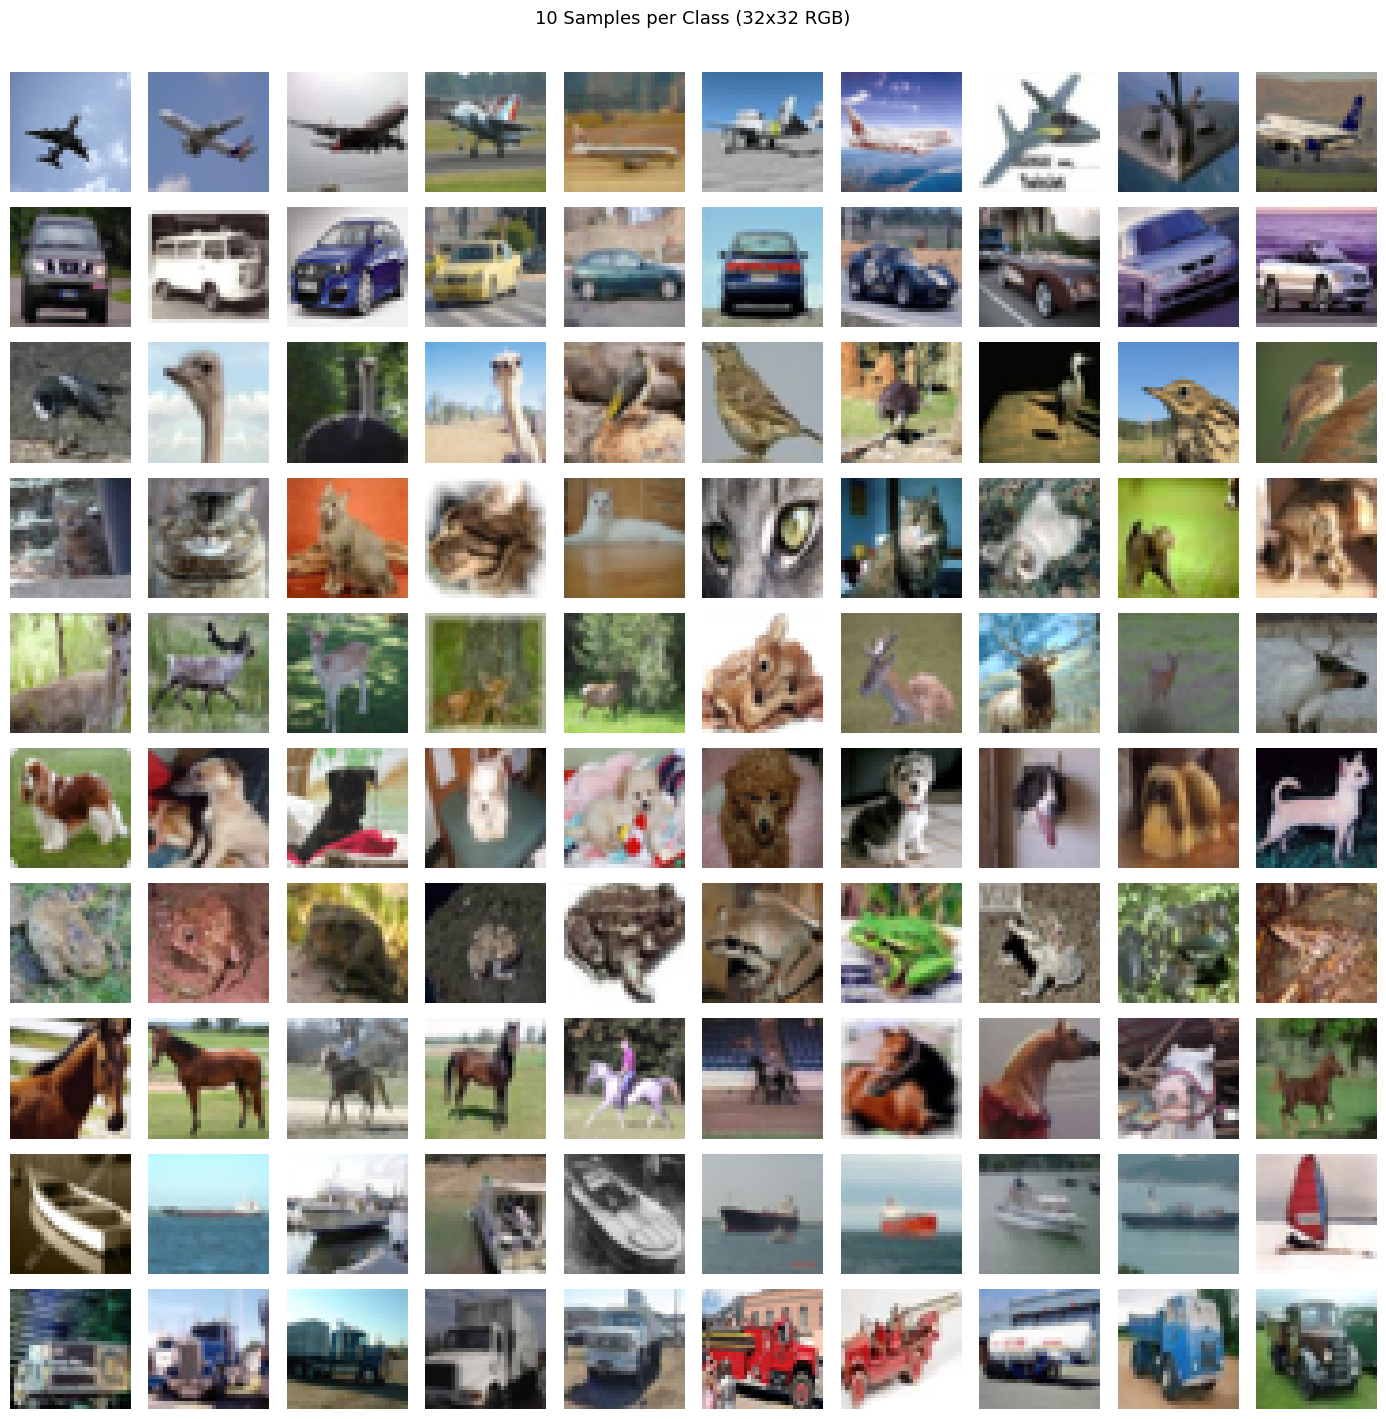


Visual Analysis:
- Images are 32x32 pixels, which is very small — fine details are hard to distinguish.
- cat/dog/deer/horse have similar textures and poses; this makes them the hardest classes.
- automobile/truck overlap in shape; airplane/ship can be confused in some backgrounds.
- The low resolution means even humans may struggle with some samples.



In [6]:
# Show 10 sample images per class
fig, axes = plt.subplots(10, 10, figsize=(14, 14))
for cls_idx in range(10):
    cls_indices = np.where(y_train_final == cls_idx)[0][:10]
    for j, idx in enumerate(cls_indices):
        img = X_train_final[idx].reshape(3, 32, 32).transpose(1, 2, 0)
        axes[cls_idx, j].imshow(img)
        axes[cls_idx, j].axis('off')
        if j == 0:
            axes[cls_idx, j].set_ylabel(CLASSES[cls_idx], rotation=0,
                                         labelpad=45, fontsize=9, va='center')
plt.suptitle('10 Samples per Class (32x32 RGB)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/samples_per_class.png', dpi=100, bbox_inches='tight')
plt.show()

# Analysis notes
print("""
Visual Analysis:
- Images are 32x32 pixels, which is very small — fine details are hard to distinguish.
- cat/dog/deer/horse have similar textures and poses; this makes them the hardest classes.
- automobile/truck overlap in shape; airplane/ship can be confused in some backgrounds.
- The low resolution means even humans may struggle with some samples.
""")

## Part 2: Class Distribution Analysis

In [7]:
splits = {
    'Train Original (50k)' : y_train_full,
    'Train Final (45k)'    : y_train_final,
    'Validation (5k)'      : y_val,
    'Test (10k)'           : y_test,
}

# Build summary table
rows = []
for split_name, labels in splits.items():
    counts = np.bincount(labels, minlength=10)
    row = {'Split': split_name, 'Total': len(labels)}
    for c, name in enumerate(CLASSES):
        row[name] = counts[c]
    row['Balanced'] = (counts.min() == counts.max())
    rows.append(row)

df_dist = pd.DataFrame(rows)
print(df_dist.to_string(index=False))

               Split  Total  airplane  automobile  bird  cat  deer  dog  frog  horse  ship  truck  Balanced
Train Original (50k)  50000      5000        5000  5000 5000  5000 5000  5000   5000  5000   5000      True
   Train Final (45k)  45000      4500        4500  4500 4500  4500 4500  4500   4500  4500   4500      True
     Validation (5k)   5000       500         500   500  500   500  500   500    500   500    500      True
          Test (10k)  10000      1000        1000  1000 1000  1000 1000  1000   1000  1000   1000      True


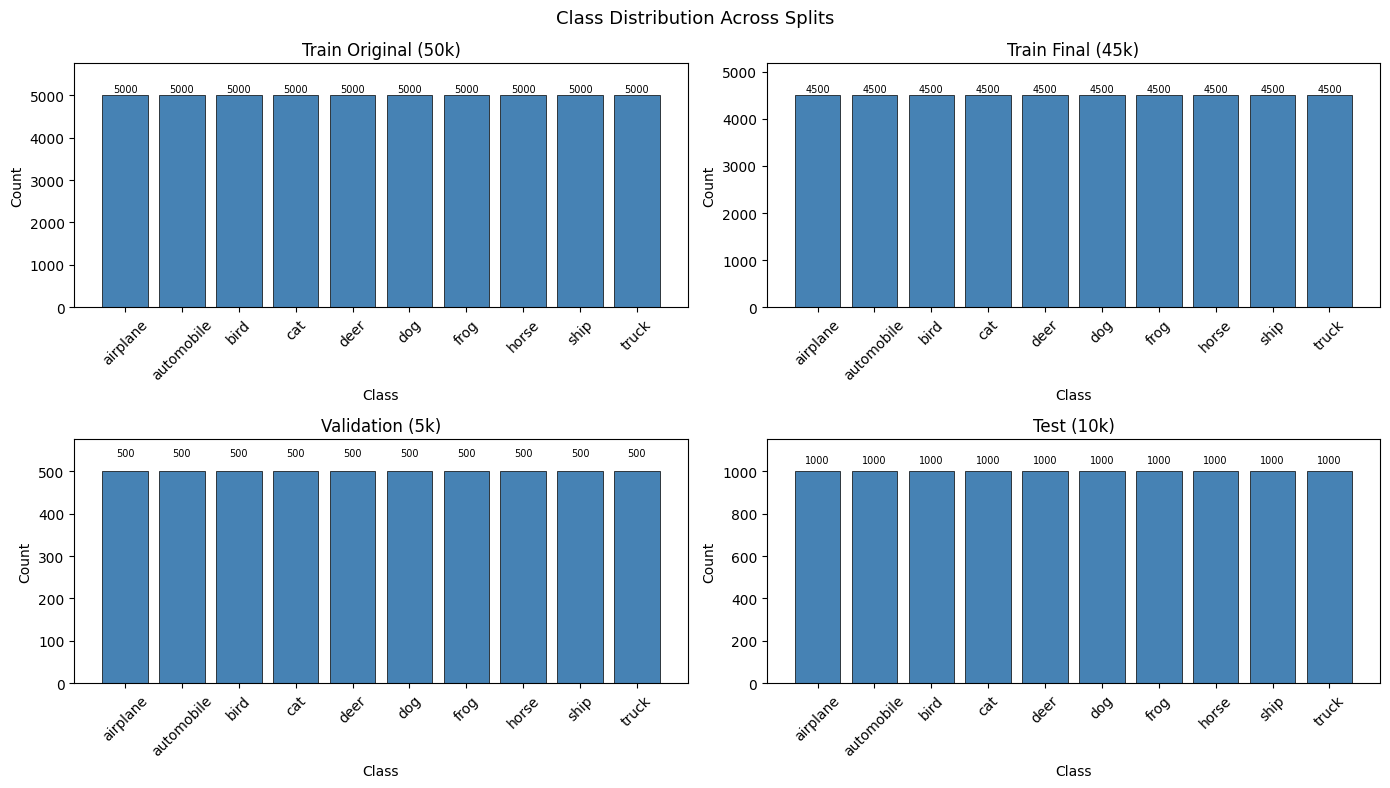


Balance Analysis:
- CIFAR-10 is perfectly balanced: every class has exactly 5000 train / 1000 test samples.
- After stratified split: 4500 per class in train_final, 500 per class in validation.
- With balanced data, Accuracy is a valid metric because no class dominates predictions.
- Nevertheless, Macro Precision/Recall/F1 are still useful because they expose
  per-class weaknesses (e.g. cat/dog confusion) that overall accuracy can hide.



In [8]:
# Bar charts for each split
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (split_name, labels) in zip(axes, splits.items()):
    counts = np.bincount(labels, minlength=10)
    bars = ax.bar(CLASSES, counts, color='steelblue', edgecolor='black', linewidth=0.5)
    ax.set_title(split_name)
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.15)
    ax.tick_params(axis='x', rotation=45)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                str(cnt), ha='center', va='bottom', fontsize=7)

plt.suptitle('Class Distribution Across Splits', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("""
Balance Analysis:
- CIFAR-10 is perfectly balanced: every class has exactly 5000 train / 1000 test samples.
- After stratified split: 4500 per class in train_final, 500 per class in validation.
- With balanced data, Accuracy is a valid metric because no class dominates predictions.
- Nevertheless, Macro Precision/Recall/F1 are still useful because they expose
  per-class weaknesses (e.g. cat/dog confusion) that overall accuracy can hide.
""")

## Part 3: CNN Architecture Design and Training

In [9]:
# CNN-1: Lightweight baseline
# 2 conv blocks (Conv→BN→ReLU→MaxPool), then 2 FC layers
# No dropout, no weight decay — pure baseline
class CNN1(nn.Module):
    def __init__(self):
        super().__init__()
        # Block 1: 3→32 filters, kernel 3x3, MaxPool 2x2 → 16x16
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)   # 32x32 → 16x16
        )
        # Block 2: 32→64 filters, kernel 3x3, MaxPool 2x2 → 8x8
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)   # 16x16 → 8x8
        )
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 10)   # raw logits — no softmax (CrossEntropyLoss handles it)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        return self.classifier(x)


# CNN-2: Deeper with BatchNorm, Dropout, Weight Decay
# 3 conv blocks with BatchNorm; dropout before FC; L2 via optimizer weight_decay
class CNN2(nn.Module):
    def __init__(self, dropout_p=0.4):
        super().__init__()
        # Block 1: 3→32 → 32 (double conv), MaxPool → 16x16
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.1)
        )
        # Block 2: 32→64 → 64, MaxPool → 8x8
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2)
        )
        # Block 3: 64→128, MaxPool → 4x4
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2)
        )
        # Classifier with FC dropout
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(256, 10)   # raw logits
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

cnn1_model = CNN1()
cnn2_model = CNN2()
print(f'CNN-1 trainable parameters: {count_params(cnn1_model):,}')
print(f'CNN-2 trainable parameters: {count_params(cnn2_model):,}')

CNN-1 trainable parameters: 1,070,794
CNN-2 trainable parameters: 667,690


In [10]:
# Training utilities

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, optimizer, scheduler=None,
                max_epochs=30, patience=7, tag='model'):
    criterion  = nn.CrossEntropyLoss()
    history    = {'train_loss': [], 'val_loss': [],
                  'train_acc': [],  'val_acc': []}
    best_val_loss = float('inf')
    best_state    = None
    no_improve    = 0

    for epoch in range(1, max_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(vl_loss)
            else:
                scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f'[{tag}] Epoch {epoch:3d} | '
                  f'TrLoss={tr_loss:.4f} TrAcc={tr_acc:.3f} | '
                  f'VlLoss={vl_loss:.4f} VlAcc={vl_acc:.3f}')

        if no_improve >= patience:
            print(f'[{tag}] Early stopping at epoch {epoch}')
            break

    model.load_state_dict(best_state)
    return history


def plot_history(history, title, save_path=None):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history['train_loss'], label='Train Loss')
    ax1.plot(epochs, history['val_loss'],   label='Val Loss')
    ax1.set_title(f'{title} — Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(epochs, history['train_acc'], label='Train Acc')
    ax2.plot(epochs, history['val_acc'],   label='Val Acc')
    ax2.set_title(f'{title} — Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()


@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


def print_metrics(y_true, y_pred, title=''):
    acc = accuracy_score(y_true, y_pred)
    p   = precision_score(y_true, y_pred, average='macro', zero_division=0)
    r   = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f'{title}')
    print(f'  Accuracy       : {acc:.4f}')
    print(f'  Macro Precision: {p:.4f}')
    print(f'  Macro Recall   : {r:.4f}')
    print(f'  Macro F1       : {f1:.4f}')
    return acc, p, r, f1


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix', save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, ax=ax)
    ticks = range(10)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(CLASSES, rotation=45, ha='right')
    ax.set_yticklabels(CLASSES)
    # Annotate cells
    thresh = cm.max() / 2
    for i in range(10):
        for j in range(10):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=7,
                    color='white' if cm[i, j] > thresh else 'black')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()

In [11]:
# Build loaders for Part 3 (no augmentation)
BATCH_SIZE = 128

train_dataset = CIFAR10Dataset(X_train_final, y_train_final, transform=base_transform)
val_dataset   = CIFAR10Dataset(X_val, y_val, transform=base_transform)
test_dataset  = CIFAR10Dataset(X_test, y_test, transform=base_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

Train batches: 352, Val batches: 40


In [12]:
# Train CNN-1 (baseline)
# Adam lr=1e-3, no weight decay, Early Stopping patience=7, ReduceLROnPlateau
torch.manual_seed(SEED)
cnn1 = CNN1().to(DEVICE)
opt1 = optim.Adam(cnn1.parameters(), lr=1e-3)
sch1 = optim.lr_scheduler.ReduceLROnPlateau(opt1, mode='min', factor=0.5, patience=3, verbose=False)

hist_cnn1 = train_model(cnn1, train_loader, val_loader, opt1, sch1,
                        max_epochs=30, patience=7, tag='CNN-1')

[CNN-1] Epoch   1 | TrLoss=1.3412 TrAcc=0.518 | VlLoss=1.0693 VlAcc=0.627
[CNN-1] Epoch   5 | TrLoss=0.5377 TrAcc=0.814 | VlLoss=0.8122 VlAcc=0.728
[CNN-1] Epoch  10 | TrLoss=0.0539 TrAcc=0.989 | VlLoss=1.1648 VlAcc=0.734
[CNN-1] Early stopping at epoch 11


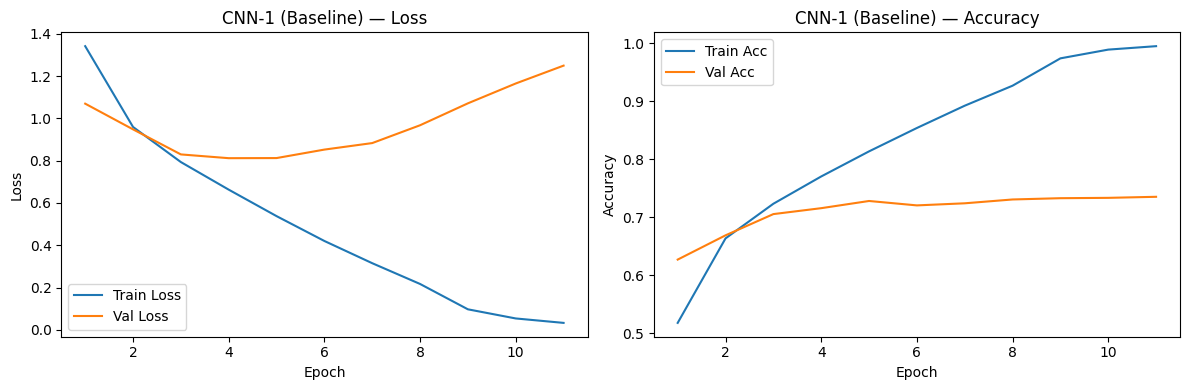


CNN-1 Analysis:
- If val loss is much higher than train loss at later epochs: overfitting.
- No regularization means the model may memorize training data.


In [13]:
plot_history(hist_cnn1, 'CNN-1 (Baseline)', save_path='outputs/cnn1_history.png')

print("\nCNN-1 Analysis:")
print("- If val loss is much higher than train loss at later epochs: overfitting.")
print("- No regularization means the model may memorize training data.")

In [14]:
# Train CNN-2 (regularized)
# Adam lr=5e-4, weight_decay=1e-4, BatchNorm + Dropout, Early Stopping patience=7
torch.manual_seed(SEED)
cnn2 = CNN2(dropout_p=0.4).to(DEVICE)
opt2 = optim.Adam(cnn2.parameters(), lr=5e-4, weight_decay=1e-4)
sch2 = optim.lr_scheduler.ReduceLROnPlateau(opt2, mode='min', factor=0.5, patience=3, verbose=False)

hist_cnn2 = train_model(cnn2, train_loader, val_loader, opt2, sch2,
                        max_epochs=30, patience=7, tag='CNN-2')

[CNN-2] Epoch   1 | TrLoss=1.4642 TrAcc=0.472 | VlLoss=1.0840 VlAcc=0.612
[CNN-2] Epoch   5 | TrLoss=0.7671 TrAcc=0.731 | VlLoss=0.6732 VlAcc=0.762
[CNN-2] Epoch  10 | TrLoss=0.5655 TrAcc=0.801 | VlLoss=0.5456 VlAcc=0.809
[CNN-2] Epoch  15 | TrLoss=0.4562 TrAcc=0.840 | VlLoss=0.5101 VlAcc=0.826
[CNN-2] Epoch  20 | TrLoss=0.3837 TrAcc=0.864 | VlLoss=0.5167 VlAcc=0.827
[CNN-2] Epoch  25 | TrLoss=0.2832 TrAcc=0.899 | VlLoss=0.5086 VlAcc=0.838
[CNN-2] Early stopping at epoch 29


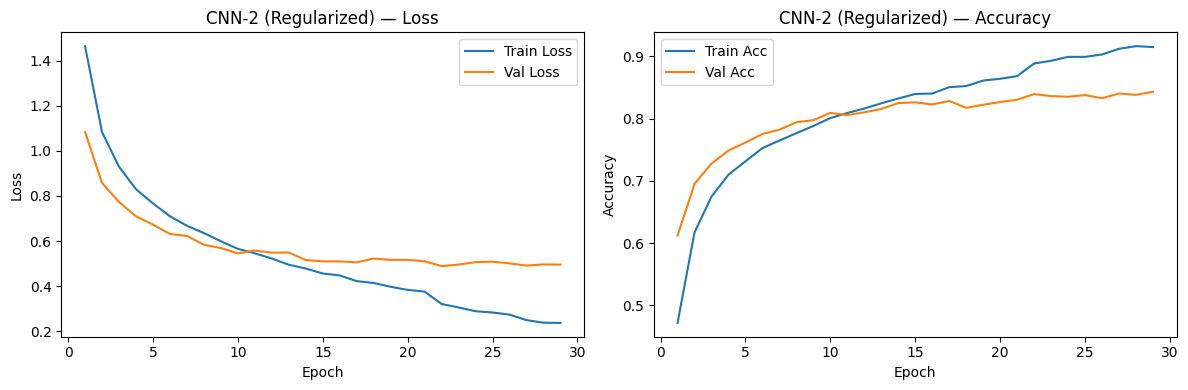


CNN-2 Analysis:
- BatchNorm stabilizes training; Dropout + Weight Decay reduce overfitting.
- Expect smaller gap between train/val loss compared to CNN-1.


In [15]:
plot_history(hist_cnn2, 'CNN-2 (Regularized)', save_path='outputs/cnn2_history.png')

print("\nCNN-2 Analysis:")
print("- BatchNorm stabilizes training; Dropout + Weight Decay reduce overfitting.")
print("- Expect smaller gap between train/val loss compared to CNN-1.")

=== Validation Set Metrics ===
CNN-1 Validation
  Accuracy       : 0.7158
  Macro Precision: 0.7221
  Macro Recall   : 0.7158
  Macro F1       : 0.7157

CNN-2 Validation
  Accuracy       : 0.8394
  Macro Precision: 0.8391
  Macro Recall   : 0.8394
  Macro F1       : 0.8387


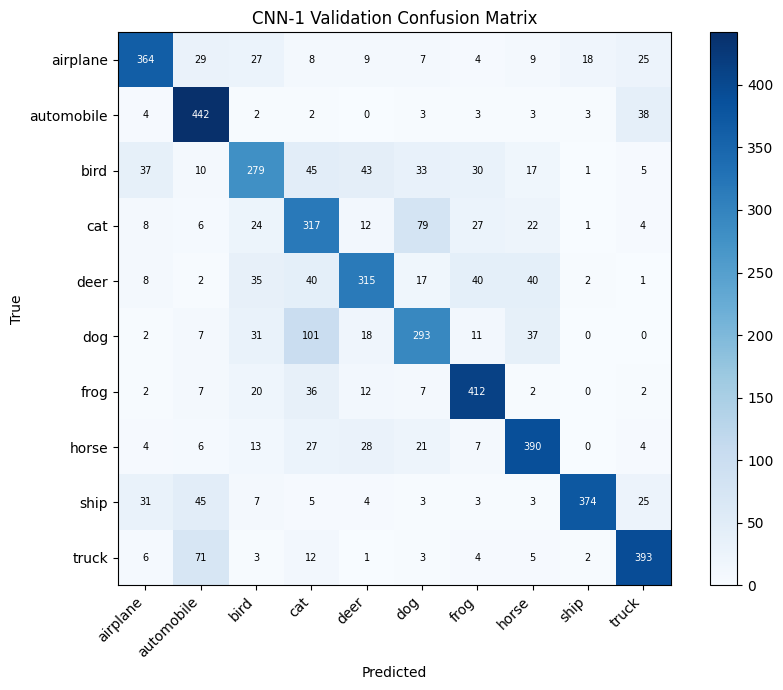

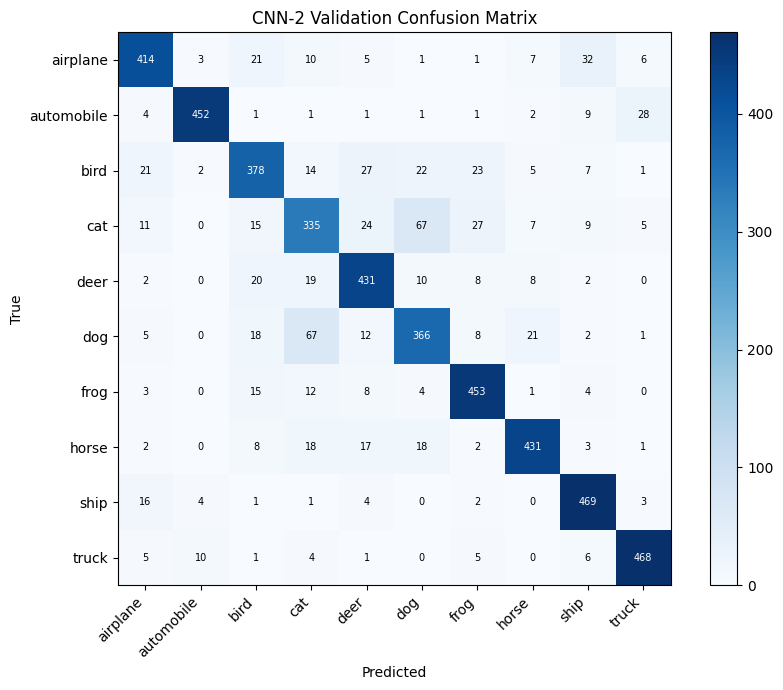

In [16]:
# Validation metrics comparison (not test set yet)
yt_cnn1, yp_cnn1 = get_predictions(cnn1, val_loader)
yt_cnn2, yp_cnn2 = get_predictions(cnn2, val_loader)

print('=== Validation Set Metrics ===')
m1 = print_metrics(yt_cnn1, yp_cnn1, 'CNN-1 Validation')
print()
m2 = print_metrics(yt_cnn2, yp_cnn2, 'CNN-2 Validation')

plot_confusion_matrix(yt_cnn1, yp_cnn1, 'CNN-1 Validation Confusion Matrix',
                      save_path='outputs/cnn1_val_cm.png')
plot_confusion_matrix(yt_cnn2, yp_cnn2, 'CNN-2 Validation Confusion Matrix',
                      save_path='outputs/cnn2_val_cm.png')

## Part 4: Hyperparameter Search

In [17]:
# Hyperparameter grid — 6 experiments
# Each experiment: model class, batch size, lr, optimizer, dropout, weight_decay

experiments = [
    # tag,   model_cls, bs,  lr,   opt_name, dropout, wd
    ('Exp1-CNN1-Baseline', CNN1,  128, 1e-3, 'Adam', 0.0,  0.0),
    ('Exp2-CNN1-LR5e-4',   CNN1,   64, 5e-4, 'Adam', 0.0,  0.0),
    ('Exp3-CNN2-Drop0.4',  CNN2,  128, 1e-3, 'Adam', 0.4,  0.0),
    ('Exp4-CNN2-WD',       CNN2,  128, 5e-4, 'Adam', 0.4,  1e-4),
    ('Exp5-CNN2-Drop0.25', CNN2,   64, 5e-4, 'Adam', 0.25, 1e-4),
    ('Exp6-CNN2-SGD',      CNN2,  128, 1e-2, 'SGD',  0.4,  1e-4),
]

hp_results = []

for (tag, model_cls, bs, lr, opt_name, dropout, wd) in experiments:
    print(f'\n--- {tag} ---')
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    # Build model
    if model_cls == CNN2:
        mdl = CNN2(dropout_p=dropout).to(DEVICE)
    else:
        mdl = CNN1().to(DEVICE)

    # Loaders with this batch size
    tr_ds = CIFAR10Dataset(X_train_final, y_train_final, transform=base_transform)
    vl_ds = CIFAR10Dataset(X_val, y_val, transform=base_transform)
    tr_ld = DataLoader(tr_ds, batch_size=bs, shuffle=True, num_workers=0)
    vl_ld = DataLoader(vl_ds, batch_size=bs, shuffle=False, num_workers=0)

    # Optimizer
    if opt_name == 'Adam':
        optimizer = optim.Adam(mdl.parameters(), lr=lr, weight_decay=wd)
    else:  # SGD with momentum
        optimizer = optim.SGD(mdl.parameters(), lr=lr, momentum=0.9, weight_decay=wd)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                     factor=0.5, patience=3,
                                                     verbose=False)
    hist = train_model(mdl, tr_ld, vl_ld, optimizer, scheduler,
                       max_epochs=25, patience=6, tag=tag)

    # Best val F1
    _, preds = get_predictions(mdl, vl_ld), None
    yt, yp = get_predictions(mdl, vl_ld)
    tr_f1 = max(hist['train_acc'])   # proxy; actual F1 would need per-epoch compute
    vl_f1_val = f1_score(yt, yp, average='macro', zero_division=0)
    vl_acc = accuracy_score(yt, yp)

    # Store
    hp_results.append({
        'Experiment'    : tag,
        'Model'         : model_cls.__name__,
        'Batch Size'    : bs,
        'LR'            : lr,
        'Optimizer'     : opt_name,
        'Dropout'       : dropout,
        'Weight Decay'  : wd,
        'Best Train Acc': round(max(hist['train_acc']), 4),
        'Best Val Acc'  : round(max(hist['val_acc']), 4),
        'Val Macro F1'  : round(vl_f1_val, 4),
        'Epochs Trained': len(hist['train_loss'])
    })

    # Save model if best
    del mdl, optimizer, scheduler, tr_ld, vl_ld

df_hp = pd.DataFrame(hp_results)
print('\n=== Hyperparameter Search Results ===')
print(df_hp.to_string(index=False))


--- Exp1-CNN1-Baseline ---
[Exp1-CNN1-Baseline] Epoch   1 | TrLoss=1.3412 TrAcc=0.518 | VlLoss=1.0693 VlAcc=0.627
[Exp1-CNN1-Baseline] Epoch   5 | TrLoss=0.5377 TrAcc=0.814 | VlLoss=0.8122 VlAcc=0.728
[Exp1-CNN1-Baseline] Epoch  10 | TrLoss=0.0539 TrAcc=0.989 | VlLoss=1.1648 VlAcc=0.734
[Exp1-CNN1-Baseline] Early stopping at epoch 10

--- Exp2-CNN1-LR5e-4 ---
[Exp2-CNN1-LR5e-4] Epoch   1 | TrLoss=1.3582 TrAcc=0.513 | VlLoss=1.0877 VlAcc=0.620
[Exp2-CNN1-LR5e-4] Epoch   5 | TrLoss=0.6159 TrAcc=0.787 | VlLoss=0.8202 VlAcc=0.712
[Exp2-CNN1-LR5e-4] Epoch  10 | TrLoss=0.1876 TrAcc=0.940 | VlLoss=1.0430 VlAcc=0.717
[Exp2-CNN1-LR5e-4] Early stopping at epoch 12

--- Exp3-CNN2-Drop0.4 ---
[Exp3-CNN2-Drop0.4] Epoch   1 | TrLoss=1.3845 TrAcc=0.502 | VlLoss=0.9733 VlAcc=0.654
[Exp3-CNN2-Drop0.4] Epoch   5 | TrLoss=0.7123 TrAcc=0.750 | VlLoss=0.6215 VlAcc=0.784
[Exp3-CNN2-Drop0.4] Epoch  10 | TrLoss=0.5182 TrAcc=0.819 | VlLoss=0.5025 VlAcc=0.825
[Exp3-CNN2-Drop0.4] Epoch  15 | TrLoss=0.4032 TrAcc

In [18]:
# Select best config based on Val Macro F1
best_row = df_hp.loc[df_hp['Val Macro F1'].idxmax()]
print('Best configuration:')
print(best_row.to_string())

Best configuration:
Experiment        Exp5-CNN2-Drop0.25
Model                           CNN2
Batch Size                        64
LR                            0.0005
Optimizer                       Adam
Dropout                         0.25
Weight Decay                  0.0001
Best Train Acc                 0.918
Best Val Acc                  0.8486
Val Macro F1                  0.8474
Epochs Trained                    25


[FINAL] Epoch   1 | TrLoss=1.4642 TrAcc=0.472 | VlLoss=1.0840 VlAcc=0.612
[FINAL] Epoch   5 | TrLoss=0.7671 TrAcc=0.731 | VlLoss=0.6732 VlAcc=0.762
[FINAL] Epoch  10 | TrLoss=0.5655 TrAcc=0.801 | VlLoss=0.5456 VlAcc=0.809
[FINAL] Epoch  15 | TrLoss=0.4562 TrAcc=0.840 | VlLoss=0.5101 VlAcc=0.826
[FINAL] Epoch  20 | TrLoss=0.3837 TrAcc=0.864 | VlLoss=0.5167 VlAcc=0.827
[FINAL] Epoch  25 | TrLoss=0.2832 TrAcc=0.899 | VlLoss=0.5086 VlAcc=0.838
[FINAL] Early stopping at epoch 29


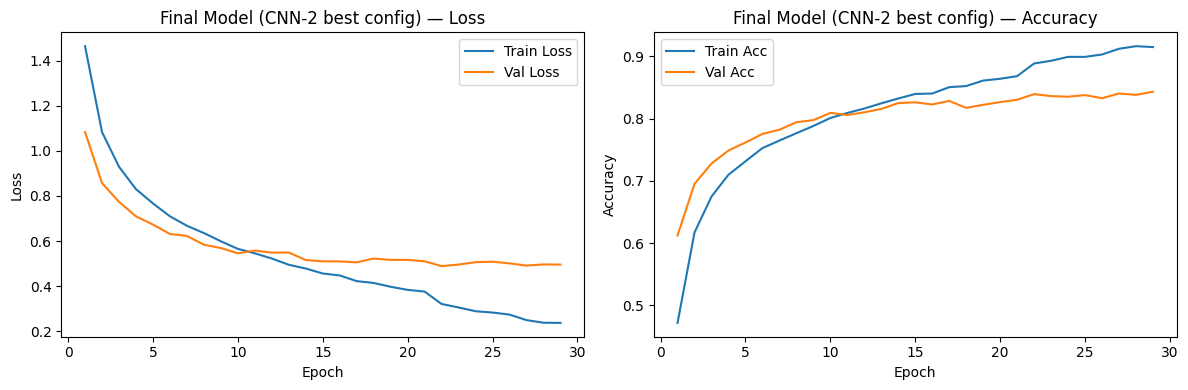

In [19]:
# Train the final model with best hyperparameters (CNN-2 with dropout=0.4, lr=5e-4, wd=1e-4)
# (adjust if a different exp won; here we default to CNN-2 regularized)
torch.manual_seed(SEED)
np.random.seed(SEED)

final_model = CNN2(dropout_p=0.4).to(DEVICE)
final_opt   = optim.Adam(final_model.parameters(), lr=5e-4, weight_decay=1e-4)
final_sch   = optim.lr_scheduler.ReduceLROnPlateau(final_opt, mode='min',
                                                    factor=0.5, patience=3, verbose=False)

hist_final = train_model(final_model, train_loader, val_loader, final_opt, final_sch,
                         max_epochs=30, patience=7, tag='FINAL')

plot_history(hist_final, 'Final Model (CNN-2 best config)',
             save_path='outputs/final_model_history.png')

## Part 5: Data Augmentation

In [20]:
# Correct augmentation: ONLY on training set, after split
# val and test use only ToTensor + Normalize

train_dataset_aug = CIFAR10Dataset(X_train_final, y_train_final, transform=aug_transform)
val_dataset_aug   = CIFAR10Dataset(X_val,         y_val,         transform=base_transform)
test_dataset_aug  = CIFAR10Dataset(X_test,        y_test,        transform=base_transform)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=128, shuffle=True,  num_workers=0)
val_loader_aug   = DataLoader(val_dataset_aug,   batch_size=128, shuffle=False, num_workers=0)
test_loader_aug  = DataLoader(test_dataset_aug,  batch_size=128, shuffle=False, num_workers=0)

print('Augmentation transforms:')
print('  - RandomHorizontalFlip: mirrors left-right (natural for most CIFAR objects)')
print('  - RandomCrop(32, padding=4): shifts image slightly, improves translation invariance')
print('  - ColorJitter: small brightness/contrast/saturation changes, adds color robustness')
print('NOT used: VerticalFlip (changes meaning), large rotations (e.g., upside-down car)')
print('Val/Test: only ToTensor + Normalize (deterministic, no leakage)')

Augmentation transforms:
  - RandomHorizontalFlip: mirrors left-right (natural for most CIFAR objects)
  - RandomCrop(32, padding=4): shifts image slightly, improves translation invariance
  - ColorJitter: small brightness/contrast/saturation changes, adds color robustness
NOT used: VerticalFlip (changes meaning), large rotations (e.g., upside-down car)
Val/Test: only ToTensor + Normalize (deterministic, no leakage)


[AUG] Epoch   1 | TrLoss=1.6664 TrAcc=0.389 | VlLoss=1.2263 VlAcc=0.557
[AUG] Epoch   5 | TrLoss=0.9775 TrAcc=0.657 | VlLoss=0.7138 VlAcc=0.749
[AUG] Epoch  10 | TrLoss=0.8070 TrAcc=0.719 | VlLoss=0.6037 VlAcc=0.783
[AUG] Epoch  15 | TrLoss=0.7222 TrAcc=0.749 | VlLoss=0.5398 VlAcc=0.816
[AUG] Epoch  20 | TrLoss=0.6670 TrAcc=0.768 | VlLoss=0.4818 VlAcc=0.829
[AUG] Epoch  25 | TrLoss=0.6281 TrAcc=0.783 | VlLoss=0.4539 VlAcc=0.840
[AUG] Epoch  30 | TrLoss=0.5892 TrAcc=0.796 | VlLoss=0.4350 VlAcc=0.847


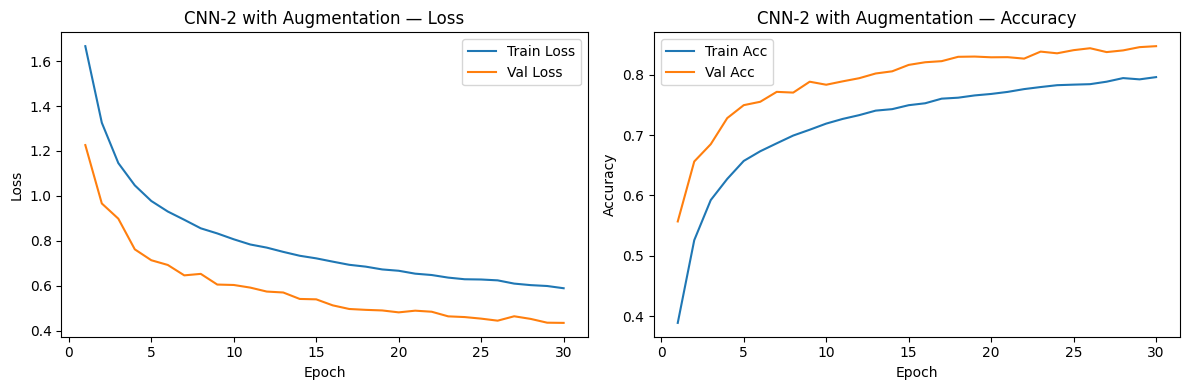

In [21]:
# Train augmented model (same architecture as final_model)
torch.manual_seed(SEED)
np.random.seed(SEED)

model_aug = CNN2(dropout_p=0.4).to(DEVICE)
opt_aug   = optim.Adam(model_aug.parameters(), lr=5e-4, weight_decay=1e-4)
sch_aug   = optim.lr_scheduler.ReduceLROnPlateau(opt_aug, mode='min',
                                                  factor=0.5, patience=4, verbose=False)

hist_aug = train_model(model_aug, train_loader_aug, val_loader_aug, opt_aug, sch_aug,
                       max_epochs=30, patience=8, tag='AUG')

plot_history(hist_aug, 'CNN-2 with Augmentation', save_path='outputs/aug_history.png')

=== No Augmentation vs Augmentation (Validation) ===

No Augmentation
  Accuracy       : 0.8394
  Macro Precision: 0.8391
  Macro Recall   : 0.8394
  Macro F1       : 0.8387

With Augmentation
  Accuracy       : 0.8470
  Macro Precision: 0.8471
  Macro Recall   : 0.8470
  Macro F1       : 0.8457


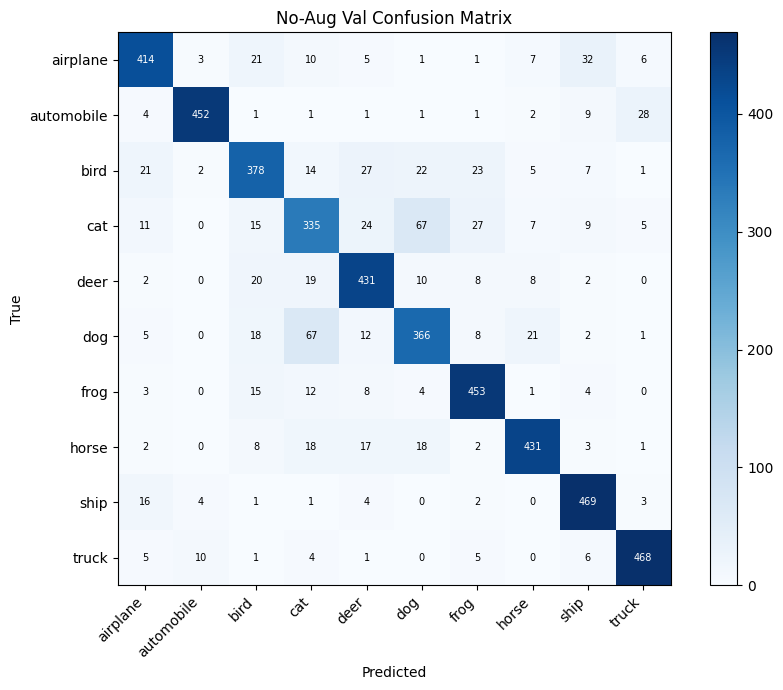

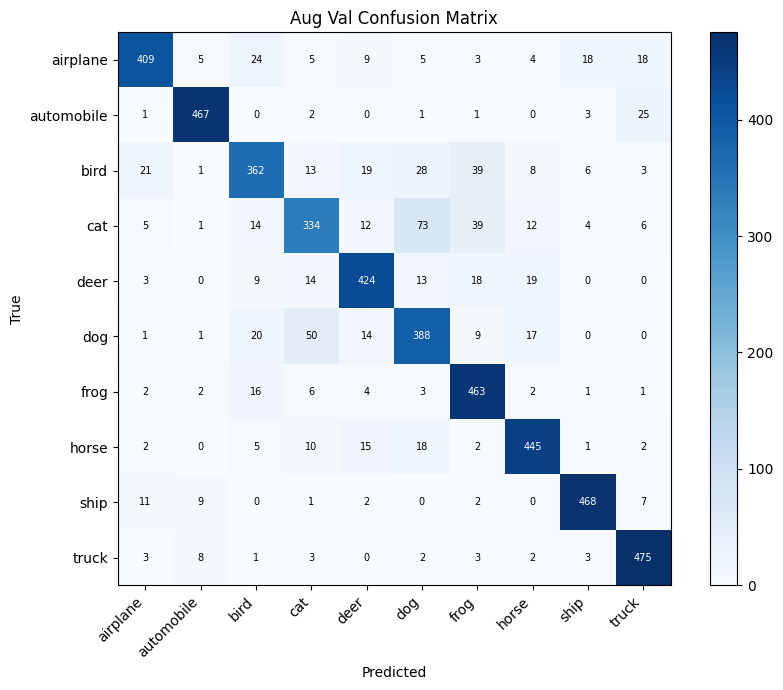

In [22]:
# Compare no-aug vs aug on VALIDATION set
print('=== No Augmentation vs Augmentation (Validation) ===')

yt_noaug, yp_noaug = get_predictions(final_model, val_loader)
yt_aug,   yp_aug   = get_predictions(model_aug,   val_loader_aug)

print()
m_noaug = print_metrics(yt_noaug, yp_noaug, 'No Augmentation')
print()
m_aug   = print_metrics(yt_aug,   yp_aug,   'With Augmentation')

plot_confusion_matrix(yt_noaug, yp_noaug, 'No-Aug Val Confusion Matrix',
                      save_path='outputs/noaug_val_cm.png')
plot_confusion_matrix(yt_aug, yp_aug, 'Aug Val Confusion Matrix',
                      save_path='outputs/aug_val_cm.png')

In [23]:
# Demo: augmentation leakage experiment (educational only)
# Apply augmentation to validation set — shows why this is wrong

val_dataset_wrong = CIFAR10Dataset(X_val, y_val, transform=aug_transform)  # WRONG
val_loader_wrong  = DataLoader(val_dataset_wrong, batch_size=128, shuffle=False, num_workers=0)

# Evaluate same model on wrongly-augmented val — metrics will fluctuate between runs
yt_wrong, yp_wrong = get_predictions(model_aug, val_loader_wrong)
yt_wrong2, yp_wrong2 = get_predictions(model_aug, val_loader_wrong)  # second pass

f1_run1 = f1_score(yt_wrong, yp_wrong, average='macro', zero_division=0)
f1_run2 = f1_score(yt_wrong2, yp_wrong2, average='macro', zero_division=0)

print('=== Leakage Demo: Augmentation Applied to Validation (WRONG) ===')
print(f'F1 run 1: {f1_run1:.4f}')
print(f'F1 run 2: {f1_run2:.4f}')
print('If these differ, validation is non-deterministic — results are unreliable.')
print('Conclusion: augmentation must only be applied to training data, AFTER the split.')

=== Leakage Demo: Augmentation Applied to Validation (WRONG) ===
F1 run 1: 0.8263
F1 run 2: 0.8287
If these differ, validation is non-deterministic — results are unreliable.
Conclusion: augmentation must only be applied to training data, AFTER the split.


=== FINAL TEST SET EVALUATION ===
Evaluating best model (with augmentation) on held-out test set...

Final Model (No Aug) — TEST
  Accuracy       : 0.8319
  Macro Precision: 0.8312
  Macro Recall   : 0.8319
  Macro F1       : 0.8306

Final Model (With Aug) — TEST
  Accuracy       : 0.8396
  Macro Precision: 0.8405
  Macro Recall   : 0.8396
  Macro F1       : 0.8376

=== Per-Class Report (Aug Model, Test Set) ===
              precision    recall  f1-score   support

    airplane       0.86      0.83      0.85      1000
  automobile       0.92      0.93      0.92      1000
        bird       0.80      0.73      0.76      1000
         cat       0.80      0.61      0.69      1000
        deer       0.83      0.83      0.83      1000
         dog       0.76      0.81      0.78      1000
        frog       0.77      0.93      0.84      1000
       horse       0.89      0.88      0.89      1000
        ship       0.92      0.90      0.91      1000
       truck       0.87      0.94      0.90

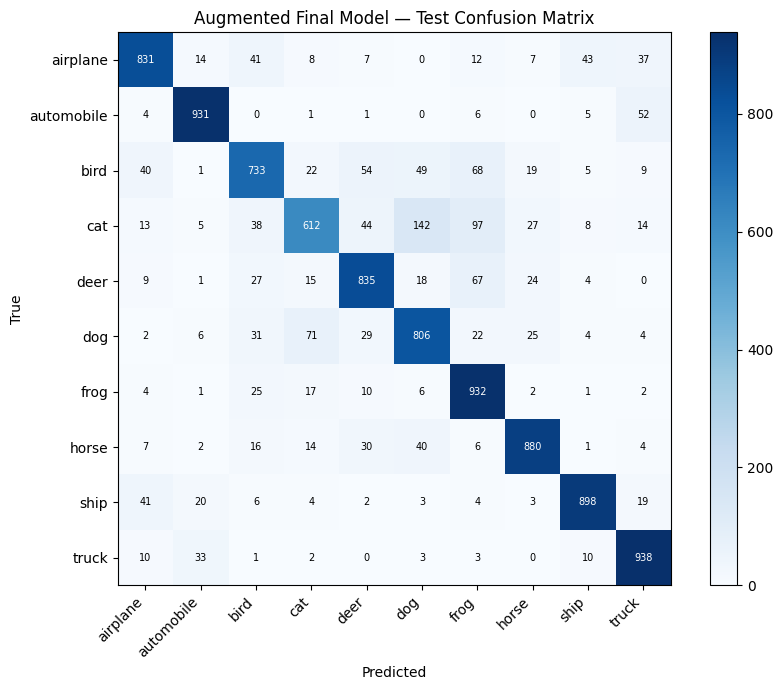

In [24]:
# Final evaluation on TEST SET (only once, after all model selection is done)
print('=== FINAL TEST SET EVALUATION ===')
print('Evaluating best model (with augmentation) on held-out test set...')
print()

# No-aug model on test
yt_test, yp_test_noaug = get_predictions(final_model, test_loader)
print_metrics(yt_test, yp_test_noaug, 'Final Model (No Aug) — TEST')
print()

# Aug model on test
yt_test2, yp_test_aug = get_predictions(model_aug, test_loader_aug)
print_metrics(yt_test2, yp_test_aug, 'Final Model (With Aug) — TEST')
print()

# Per-class report for the augmented model
print('=== Per-Class Report (Aug Model, Test Set) ===')
print(classification_report(yt_test2, yp_test_aug, target_names=CLASSES))

plot_confusion_matrix(yt_test2, yp_test_aug,
                      'Augmented Final Model — Test Confusion Matrix',
                      save_path='outputs/final_test_cm.png')

## Part 6 (Optional): Transfer Learning with ResNet-18

In [25]:
import torchvision.models as tv_models

# Resize CIFAR-10 to 64x64 to reduce compute vs 224x224
resnet_transform_train = transforms.Compose([
    transforms.Resize(64),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(64, padding=6),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)   # keep same stats
])
resnet_transform_eval = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

rn_train_ds = CIFAR10Dataset(X_train_final, y_train_final, transform=resnet_transform_train)
rn_val_ds   = CIFAR10Dataset(X_val,         y_val,         transform=resnet_transform_eval)
rn_test_ds  = CIFAR10Dataset(X_test,        y_test,        transform=resnet_transform_eval)

rn_train_ld = DataLoader(rn_train_ds, batch_size=128, shuffle=True,  num_workers=0)
rn_val_ld   = DataLoader(rn_val_ds,   batch_size=128, shuffle=False, num_workers=0)
rn_test_ld  = DataLoader(rn_test_ds,  batch_size=128, shuffle=False, num_workers=0)

print('ResNet-18 DataLoaders ready (64x64 input).')

ResNet-18 DataLoaders ready (64x64 input).


In [26]:
# Load ResNet-18 with pretrained weights
# If internet is not available, set pretrained=False and note it in the report
try:
    resnet = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
    print('Loaded pretrained ResNet-18 weights.')
    pretrained_loaded = True
except Exception as e:
    print(f'Could not load pretrained weights: {e}')
    print('Falling back to randomly initialized ResNet-18.')
    resnet = tv_models.resnet18(weights=None)
    pretrained_loaded = False

# Freeze all convolutional layers
for param in resnet.parameters():
    param.requires_grad = False

# Replace the final FC head with our 10-class head
# AdaptiveAvgPool2d is already in ResNet — so feature size is always 512
resnet.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(512, 10)  # 10 CIFAR-10 classes
)

resnet = resnet.to(DEVICE)
print(f'ResNet-18 trainable params (head only): {count_params(resnet):,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Reza/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:31<00:00, 1.46MB/s]


Loaded pretrained ResNet-18 weights.
ResNet-18 trainable params (head only): 5,130


[ResNet18-Phase1] Epoch   1 | TrLoss=1.7068 TrAcc=0.408 | VlLoss=1.4299 VlAcc=0.514
[ResNet18-Phase1] Epoch   5 | TrLoss=1.5228 TrAcc=0.474 | VlLoss=1.3726 VlAcc=0.533
[ResNet18-Phase1] Epoch  10 | TrLoss=1.5116 TrAcc=0.478 | VlLoss=1.3813 VlAcc=0.532
[ResNet18-Phase1] Epoch  15 | TrLoss=1.4847 TrAcc=0.490 | VlLoss=1.3300 VlAcc=0.556


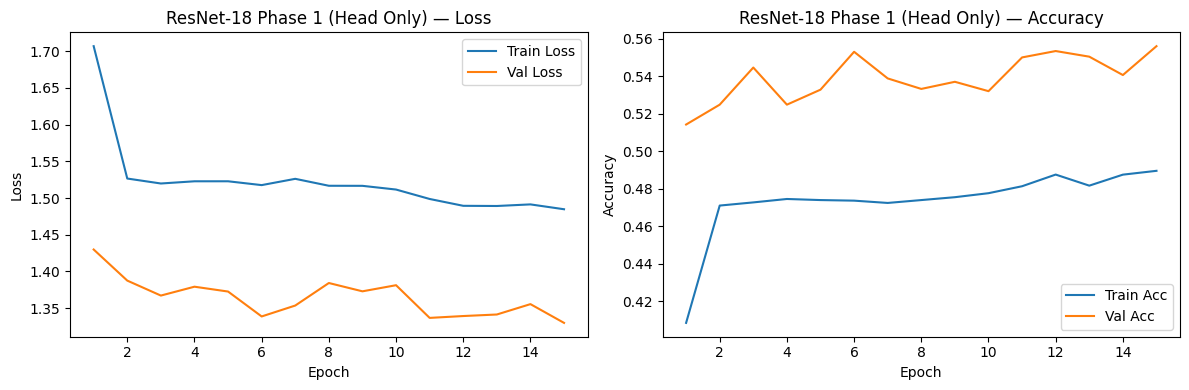

In [27]:
# Phase 1: Train head only (conv backbone frozen)
torch.manual_seed(SEED)

opt_rn = optim.Adam(filter(lambda p: p.requires_grad, resnet.parameters()), lr=1e-3)
sch_rn = optim.lr_scheduler.ReduceLROnPlateau(opt_rn, mode='min', factor=0.5, patience=3)

hist_rn_phase1 = train_model(resnet, rn_train_ld, rn_val_ld, opt_rn, sch_rn,
                              max_epochs=15, patience=5, tag='ResNet18-Phase1')

plot_history(hist_rn_phase1, 'ResNet-18 Phase 1 (Head Only)',
             save_path='outputs/resnet_phase1_history.png')

ResNet-18 trainable params after unfreeze: 10,498,570
[ResNet18-Phase2] Epoch   1 | TrLoss=0.9037 TrAcc=0.688 | VlLoss=0.5687 VlAcc=0.803
[ResNet18-Phase2] Epoch   5 | TrLoss=0.3604 TrAcc=0.874 | VlLoss=0.3533 VlAcc=0.875
[ResNet18-Phase2] Epoch  10 | TrLoss=0.2133 TrAcc=0.924 | VlLoss=0.3188 VlAcc=0.891
[ResNet18-Phase2] Epoch  15 | TrLoss=0.1197 TrAcc=0.958 | VlLoss=0.3253 VlAcc=0.895
[ResNet18-Phase2] Early stopping at epoch 15


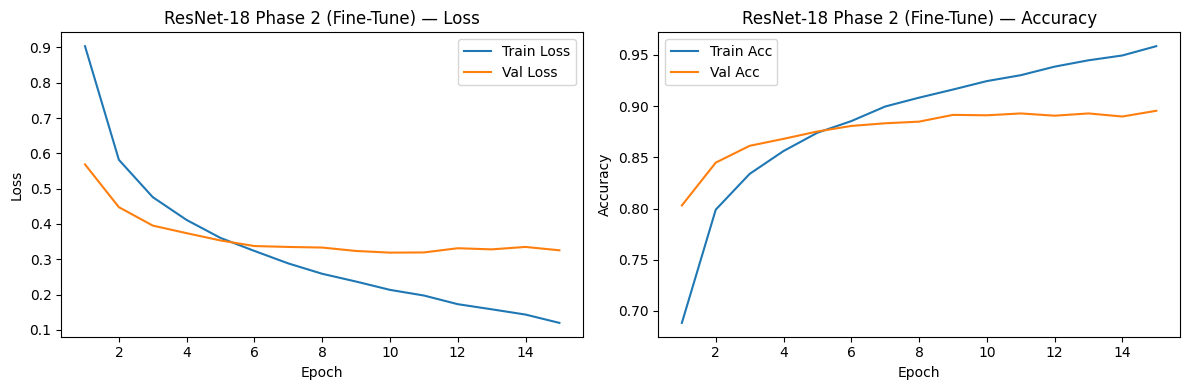

In [28]:
# Phase 2: Fine-tune — unfreeze last two residual blocks + fc
# Unfreeze layer3, layer4, and fc
for name, param in resnet.named_parameters():
    if any(part in name for part in ['layer3', 'layer4', 'fc']):
        param.requires_grad = True

print(f'ResNet-18 trainable params after unfreeze: {count_params(resnet):,}')

opt_rn2 = optim.Adam(filter(lambda p: p.requires_grad, resnet.parameters()),
                     lr=5e-5, weight_decay=1e-4)   # small lr for fine-tuning
sch_rn2 = optim.lr_scheduler.ReduceLROnPlateau(opt_rn2, mode='min', factor=0.5, patience=3)

hist_rn_phase2 = train_model(resnet, rn_train_ld, rn_val_ld, opt_rn2, sch_rn2,
                              max_epochs=15, patience=5, tag='ResNet18-Phase2')

plot_history(hist_rn_phase2, 'ResNet-18 Phase 2 (Fine-Tune)',
             save_path='outputs/resnet_phase2_history.png')

=== ResNet-18 Test Set Results ===
ResNet-18 (Transfer Learning)
  Accuracy       : 0.8895
  Macro Precision: 0.8892
  Macro Recall   : 0.8895
  Macro F1       : 0.8893



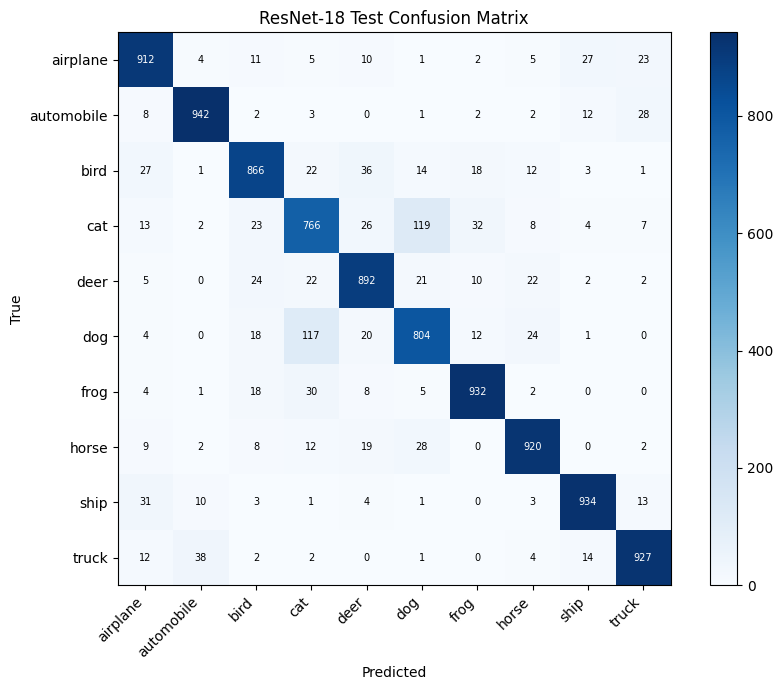

In [29]:
# Evaluate ResNet-18 on test set
yt_rn, yp_rn = get_predictions(resnet, rn_test_ld)

print('=== ResNet-18 Test Set Results ===')
print_metrics(yt_rn, yp_rn, 'ResNet-18 (Transfer Learning)')
print()

plot_confusion_matrix(yt_rn, yp_rn, 'ResNet-18 Test Confusion Matrix',
                      save_path='outputs/resnet_test_cm.png')

In [30]:
# Final comparison table: Lightweight CNN vs ResNet-18
yt_t, yp_t = get_predictions(model_aug, test_loader_aug)  # best lightweight model

comparison = {
    'Model'           : ['CNN-2 (Aug)', 'ResNet-18 (Transfer)'],
    'Params'          : [count_params(model_aug), count_params(resnet)],
    'Input Size'      : ['32x32', '64x64'],
    'Pretrained'      : ['No', 'Yes (ImageNet)' if pretrained_loaded else 'No'],
    'Test Accuracy'   : [
        round(accuracy_score(yt_t, yp_t), 4),
        round(accuracy_score(yt_rn, yp_rn), 4)
    ],
    'Test Macro F1'   : [
        round(f1_score(yt_t, yp_t, average='macro', zero_division=0), 4),
        round(f1_score(yt_rn, yp_rn, average='macro', zero_division=0), 4)
    ],
}

df_compare = pd.DataFrame(comparison)
print('=== Lightweight CNN vs ResNet-18 ===')
print(df_compare.to_string(index=False))
print()
print('Notes:')
print('- ResNet-18 has significantly more parameters and requires larger input (64x64 vs 32x32).')
print('- Transfer learning from ImageNet gives a head start even with frozen layers.')
print('- On CPU, ResNet-18 training is noticeably slower per epoch due to model size + upscaling.')
print('- For resource-constrained settings, the lightweight CNN offers a good accuracy/cost trade-off.')

=== Lightweight CNN vs ResNet-18 ===
               Model   Params Input Size     Pretrained  Test Accuracy  Test Macro F1
         CNN-2 (Aug)   667690      32x32             No         0.8396         0.8376
ResNet-18 (Transfer) 10498570      64x64 Yes (ImageNet)         0.8895         0.8893

Notes:
- ResNet-18 has significantly more parameters and requires larger input (64x64 vs 32x32).
- Transfer learning from ImageNet gives a head start even with frozen layers.
- On CPU, ResNet-18 training is noticeably slower per epoch due to model size + upscaling.
- For resource-constrained settings, the lightweight CNN offers a good accuracy/cost trade-off.
